In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

def seed_all(seed=0):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(0)

Using cuda


In [2]:
import os
import urllib.request
import tarfile

def download_and_extract(url: str, download_path: str, extract_dir: str):
    """
    Download a .tar.gz file from `url` into `download_path`
    (unless that file already exists) and then extract its
    contents into `extract_dir`.
    """
    # 1) Skip download if the archive is already present
    if os.path.isfile(download_path) and os.path.getsize(download_path) > 0:
        print(f"Archive '{download_path}' already exists; skipping download.")
    else:
        # create parent dir for the download if needed
        parent = os.path.dirname(download_path)
        if parent:
            os.makedirs(parent, exist_ok=True)

        print(f"Downloading {url} → {download_path} …")
        urllib.request.urlretrieve(url, download_path)
        print("Download complete.")

    # 2) Always make sure extract_dir exists, then extract
    os.makedirs(extract_dir, exist_ok=True)
    print(f"Extracting {download_path} → {extract_dir} …")
    with tarfile.open(download_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    print("Extraction complete.\n")


if __name__ == "__main__":
    # first archive
    download_and_extract(
        "https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz",
        "images.tar.gz",
        "data"
    )
    # second archive, same extract directory
    download_and_extract(
        "https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz",
        "annotations.tar.gz",
        "data"
    )


Archive 'images.tar.gz' already exists; skipping download.
Extracting images.tar.gz → data …


/tmp/ipykernel_22827/1760141962.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extraction complete.

Archive 'annotations.tar.gz' already exists; skipping download.
Extracting annotations.tar.gz → data …
Extraction complete.



In [3]:
from torch import nn

class UNet(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        def down_block(in_dim, out_dim):
            return nn.Sequential(
                nn.Conv2d(in_dim, out_dim, 3, 1, 1),
                nn.BatchNorm2d(out_dim),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_dim, out_dim, 3, 1, 1),
                nn.BatchNorm2d(out_dim),
                nn.ReLU(inplace=True),
            )
        
        def up_block(in_dim, h_dim, out_dim):
            return nn.Sequential(
                nn.Conv2d(in_dim, h_dim, 3, 1, 1),
                nn.BatchNorm2d(h_dim),
                nn.ReLU(inplace=True),
                nn.Conv2d(h_dim, h_dim, 3, 1, 1),
                nn.BatchNorm2d(h_dim),
                nn.ReLU(inplace=True),
                nn.ConvTranspose2d(h_dim, out_dim, 2, 2)
            )

        self.pool = nn.MaxPool2d(2, 2)
        self.down1 = down_block(3, 64)
        self.down2 = down_block(64, 128)
        self.down3 = down_block(128, 256)
        self.down4 = down_block(256, 512)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, 3, 1, 1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, 3, 1, 1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(1024, 512, 2, 2)
        )

        self.up1 = up_block(1024, 512, 256)
        self.up2 = up_block(512, 256, 128)
        self.up3 = up_block(256, 128, 64)
        self.up4 = nn.Sequential(
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        self.apply(self._init_weights)

        print(f"Number of parameters: {sum([p.numel() for p in self.parameters()])}")

    def forward(self, x):

        x1 = self.down1(x)

        x2 = self.down2(self.pool(x1))

        x3 = self.down3(self.pool(x2))

        x4 = self.down4(self.pool(x3))
        
        return self.up4(torch.cat((x1, self.up3(torch.cat((x2, self.up2(torch.cat((x3, self.up1(torch.cat((x4, self.bottleneck(self.pool(x4))), dim=1))), dim=1))), dim=1))), dim=1))
    
    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        if isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
    
model = UNet(2).to(device)

X = torch.randn(1, 3, 224, 224).to(device)

output = model(X)

print(output.shape)

Number of parameters: 31043586
torch.Size([1, 2, 224, 224])


In [4]:
from torch.utils.data import DataLoader, Dataset
import os
from torchvision.transforms import v2
from PIL import Image
import matplotlib.pyplot as plt

class OxfordPetSegmentation(Dataset):

    def __init__(self, root_dir, split, transform=None, target_transform=None, train_val_split=0.8):
        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, "images")
        self.mask_dir = os.path.join(root_dir, "annotations", "trimaps")   
        self.split = split
        self.split_dir = os.path.join(root_dir, "annotations")
        self.split_file = None

        if self.split in ["train", "val"]:
            self.split_file = os.path.join(self.split_dir, "trainval.txt")
        elif self.split == "test":
            self.split_file = os.path.join(self.split_dir, "test.txt")
        else:
            raise ValueError(f"Unknown split: {self.split}. Expected one of 'train', 'val', 'test'.")            

        self.filenames = []
        with open(self.split_file, "r") as f:
            for line in f:
                filename = line.strip().split(" ")[0].strip()
                self.filenames.append(filename)

        n = len(self.filenames)
        if self.split == "train":
            self.filenames = self.filenames[:int(train_val_split * n)]
        elif self.split == "val":
            self.filenames = self.filenames[int(train_val_split * n):]

        self.transform = transform
        self.target_transform = target_transform

        if self.transform is None:
            self.transform = v2.Compose([
                v2.ToImage(),
                v2.Resize((256, 256)),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
            ])

        if self.target_transform is None:
            self.target_transform = v2.Compose([
                v2.ToImage(),
                v2.Resize((256, 256)),
                v2.ToDtype(torch.float32),
            ])

    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        name = self.filenames[idx]
        img_path = os.path.join(self.img_dir, name + ".jpg")
        mask_path = os.path.join(self.mask_dir, name + ".png")

        image = self.transform(Image.open(img_path).convert("RGB"))
        mask = self.target_transform(Image.open(mask_path))

        return image, mask
    
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32


train_ds = OxfordPetSegmentation("data", "train", None, None, 0.9)
val_ds = OxfordPetSegmentation("data", "val", None, None, 0.9)
test_ds = OxfordPetSegmentation("data", "test", None, None)

train_dl = DataLoader(train_ds, TRAIN_BATCH_SIZE, shuffle=True, pin_memory=True)
val_dl = DataLoader(val_ds, EVAL_BATCH_SIZE, shuffle=False, pin_memory=True)
test_dl = DataLoader(test_ds, EVAL_BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train dataset size: {len(train_ds)}")
print(f"Val dataset size: {len(val_ds)}")
print(f"Test dataset size: {len(test_ds)}")

Train dataset size: 3312
Val dataset size: 368
Test dataset size: 3669


In [5]:
import torch.nn.functional as F
from tqdm.auto import tqdm

model = UNet(3).to(device)

def evaluate(model, dl):

    model.eval()
    
    batches = len(dl)

    mean_loss, mean_accuracy = 0, 0
    for X, y in tqdm(dl, desc="Eval", leave=False):
        with torch.inference_mode():
            X, y = X.to(device), (y - 1).to(device).squeeze(1).long()
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            loss = F.cross_entropy(logits, y)
            accuracy = (preds == y).float().mean()
            mean_loss += loss.item()
            mean_accuracy += accuracy.item()

    mean_loss /= batches
    mean_accuracy /= batches

    print(f"Evaluation: loss: {mean_loss:.4f} | accuracy: {mean_accuracy*100:.2f}%")


def train(model, train_dl, val_dl, opt, epochs):

    for epoch in range(1, epochs + 1):
        
        mean_loss, mean_accuracy = 0, 0
        
        print(f"EPOCH: {epoch} ================================================")

        model.train()
        batches = len(train_dl)
        for X, y in tqdm(train_dl, desc="Train", leave=False):
            opt.zero_grad()
            X, y = X.to(device), (y - 1).to(device).squeeze(1).long()
            logits = model(X)
            loss = F.cross_entropy(logits, y)

            loss.backward()

            opt.step()

            with torch.no_grad():
                preds = torch.argmax(logits, dim=1)
                accuracy = (preds == y).float().mean()
                mean_loss += loss.item()
                mean_accuracy += accuracy.item()

        mean_loss /= batches
        mean_accuracy /= batches

        print(f"Training: loss: {mean_loss:.4f} | accuracy: {mean_accuracy*100:.2f}%")

        evaluate(model, val_dl)

        print("\n")

/home/maciek/venvs/ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of parameters: 31043651


In [6]:
"""
Training loop:
1. AdamW(lr=1e-3, weight_decay=5e-2) 10 epochs 
3. AdamW(lr=1e-4, weight_decay=5e-2) 10 epochs
"""

import gc

gc.collect()
torch.cuda.empty_cache()

seed_all(0)

model = UNet(3).to(device)

gc.collect()
torch.cuda.empty_cache()

# model.load_state_dict(torch.load("model_parameters.pth"))

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-2)

train(model, train_dl, val_dl, opt, epochs=10)

opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-2)

train(model, train_dl, val_dl, opt, epochs=10)

torch.save(model.state_dict(), "model_parameters.pth")

Number of parameters: 31043651
EPOCH: 1 ================================================


Training: loss: 0.8947 | accuracy: 60.70%


Evaluation: loss: 0.6704 | accuracy: 73.01%


EPOCH: 2 ================================================


Training: loss: 0.6666 | accuracy: 73.04%


Evaluation: loss: 0.6217 | accuracy: 76.33%


EPOCH: 3 ================================================


...

Evaluation: loss: 0.2848 | accuracy: 89.14%


EPOCH: 9 ================================================


Training: loss: 0.2585 | accuracy: 90.08%


Evaluation: loss: 0.2856 | accuracy: 89.04%


EPOCH: 10 ================================================


Training: loss: 0.2541 | accuracy: 90.22%


Evaluation: loss: 0.2845 | accuracy: 89.13%




In [9]:
evaluate(model, test_dl)

Evaluation: loss: 0.2901 | accuracy: 89.15%


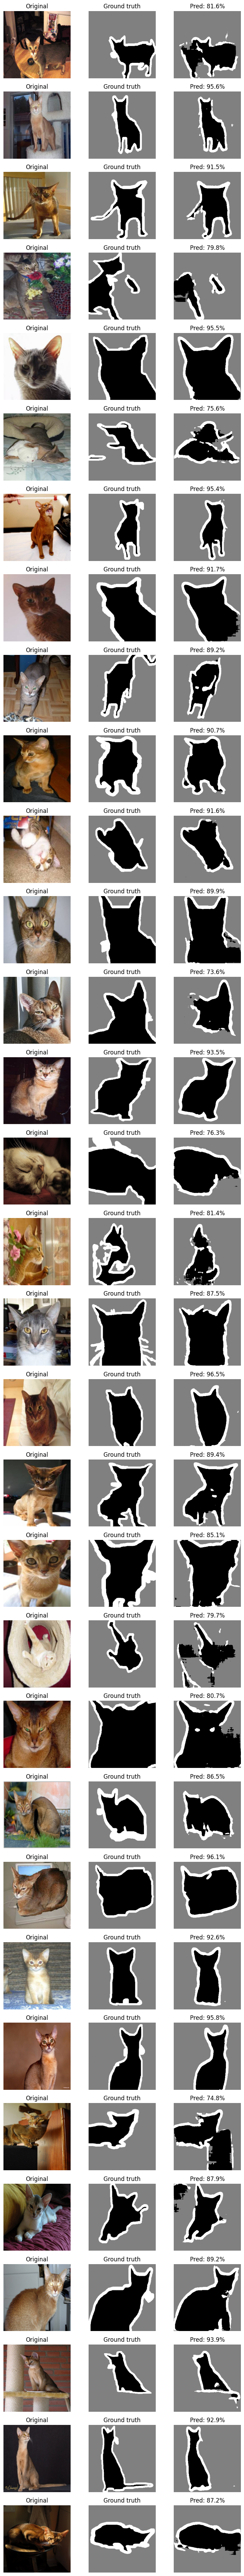

In [17]:
mean = torch.tensor([0.485,0.456,0.406], dtype=torch.float32, device=device).reshape(3, 1, 1)
std = torch.tensor([0.229,0.224,0.225], dtype=torch.float32, device=device).reshape(3, 1, 1)

def get_initial_image(img):
    return (img * std + mean).permute(1,2,0).cpu().numpy()

def plot_prediction(samples, tile_size=3):
    model.eval()
    with torch.inference_mode():
        X, y = samples[0].to(device), (samples[1] - 1).to(device).squeeze(1).long()
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        loss = F.cross_entropy(logits, y)
        accuracy = (preds == y).float().mean(dim=(1,2))

    n = X.shape[0]
    rows, cols = n, 3
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols*tile_size, rows*tile_size),
                             squeeze=False)

    for i in range(n):
        axes[i,0].imshow(get_initial_image(X[i]))
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(y[i].cpu().numpy(), cmap="gray")
        axes[i,1].set_title("Ground truth")
        axes[i,1].axis("off")

        axes[i,2].imshow(preds[i].cpu().numpy(), cmap="gray")
        axes[i,2].set_title(f"Pred: {accuracy[i].item()*100:.1f}%")
        axes[i,2].axis("off")

samples = next(iter(test_dl))
plot_prediction(samples)